# Modular Forecasting Pipeline

ProbPipe provides a modular pipeline for Bayesian inference and sequential forecasting. The key components are:

- **`Likelihood`** — abstract interface for computing log-likelihood
- **`MCMCSampler`** — TFP-backed NUTS/HMC with automatic gradient-free fallback
- **`IterativeForecaster`** — sequential Bayesian updating: each batch of data updates the posterior, which becomes the next prior

All components are **swappable**: change the likelihood, swap the sampler, or replace the prior — the pipeline structure stays the same.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from probpipe import Normal, MultivariateNormal, EmpiricalDistribution, provenance_ancestors
from probpipe.core.modeling import (
    Likelihood, GenerativeLikelihood, MCMCSampler,
    IterativeForecaster,
)
from probpipe.core.node import wffrom probpipe import mean


## Defining a Likelihood

A `Likelihood` subclass must implement `log_likelihood(params, data)` decorated with `@wf`. Here we define a simple Gaussian likelihood for estimating a 1D mean with known variance.

In [2]:
class GaussianLikelihood(Likelihood):
    """Gaussian likelihood with known variance."""

    def __init__(self, variance: float = 1.0):
        self._variance = variance
        super().__init__()

    @wf
    def log_likelihood(self, params, data):
        # params is a scalar (the mean), data is (n,)
        return jnp.sum(-0.5 * (data - params) ** 2 / self._variance)


class GaussianGenerative(GenerativeLikelihood):
    """Generate data from a Gaussian with known variance."""

    def __init__(self, variance: float = 1.0):
        self._variance = variance
        super().__init__()

    @wf
    def generate_data(self, params, n_samples):
        key = jax.random.PRNGKey(0)
        return jax.random.normal(key, (n_samples,)) * jnp.sqrt(self._variance) + params


likelihood = GaussianLikelihood(variance=1.0)
gen_likelihood = GaussianGenerative(variance=1.0)
print(f'Likelihood: {likelihood}')
print(f'Generative: {gen_likelihood}')

Likelihood: <__main__.GaussianLikelihood object at 0x108fbd910>
Generative: <__main__.GaussianGenerative object at 0x10d9c63f0>


## MCMC Inference with MCMCSampler

`MCMCSampler` runs NUTS (or HMC) via TFP. It takes a prior distribution, a likelihood, and data, then returns an `EmpiricalDistribution` of posterior samples with diagnostics and provenance.

In [3]:
# True parameter (2D) and synthetic data
true_mean = jnp.array([3.0, -1.0])
rng = np.random.default_rng(42)
data = rng.normal(size=(50, 2)) + np.array([3.0, -1.0])

# Prior: broad 2D Gaussian
prior = MultivariateNormal(
    loc=jnp.zeros(2), cov=25.0 * jnp.eye(2), name='prior'
)

# Run NUTS
sampler = MCMCSampler(algorithm='nuts', num_results=1000, num_warmup=500, seed=0)
posterior = sampler(prior=prior, likelihood=likelihood, data=data)

print(f'Posterior: {posterior}')
print(f'Posterior mean:  {mean(posterior)}')
print(f'Data mean:       {np.mean(data, axis=0)}')
print(f'True mean:       {true_mean}')
print(f'Diagnostics:     {sampler.diagnostics.summary()}')
print(f'Provenance:      {posterior.source}')


Posterior: EmpiricalDistribution(name='posterior', event_shape=(2,))
Posterior mean:  [ 2.9587367 -1.0605739]
Data mean:       [ 2.96178178 -1.062321  ]
True mean:       [ 3. -1.]
Diagnostics:     algorithm=nuts, accept_rate=0.929, final_step_size=0.1685
Provenance:      Provenance('nuts', parents=[prior])


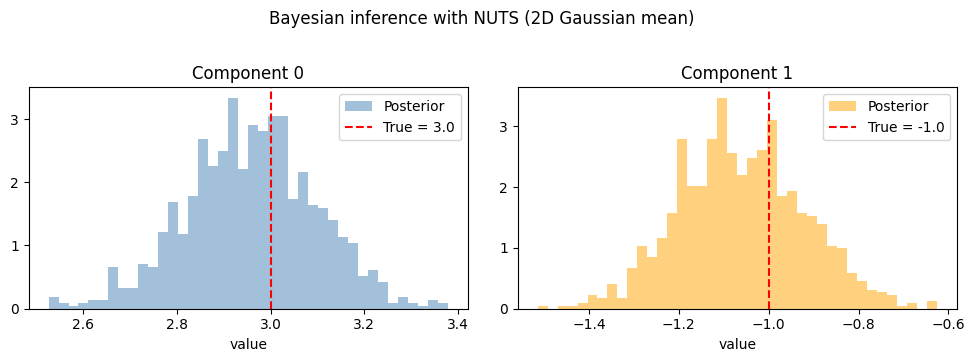

In [4]:
# Visualize posterior vs prior (marginal on first component)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

# Component 0
ax1.hist(np.array(posterior.samples[:, 0]), bins=40, density=True,
         alpha=0.5, color='steelblue', label='Posterior')
ax1.axvline(float(true_mean[0]), color='red', linestyle='--', label=f'True = {float(true_mean[0])}')
ax1.set_title('Component 0')
ax1.set_xlabel('value')
ax1.legend()

# Component 1
ax2.hist(np.array(posterior.samples[:, 1]), bins=40, density=True,
         alpha=0.5, color='orange', label='Posterior')
ax2.axvline(float(true_mean[1]), color='red', linestyle='--', label=f'True = {float(true_mean[1])}')
ax2.set_title('Component 1')
ax2.set_xlabel('value')
ax2.legend()

plt.suptitle('Bayesian inference with NUTS (2D Gaussian mean)', y=1.02)
plt.tight_layout()
plt.show()


## Sequential Bayesian Updating

`IterativeForecaster` chains updates: each new data batch updates the posterior, and the updated posterior becomes the prior for the next batch. This is the core of online Bayesian learning.

In [5]:
# Set up the forecaster
prior = MultivariateNormal(
    loc=jnp.zeros(2), cov=25.0 * jnp.eye(2), name='prior'
)
sampler = MCMCSampler(algorithm='nuts', num_results=500, num_warmup=300, seed=0)

forecaster = IterativeForecaster(
    prior=prior,
    likelihood=likelihood,
    generative_likelihood=gen_likelihood,
    approx_post=sampler,
)

# Generate 3 batches of 2D data from the true model
true_mean = np.array([2.0, -1.0])
batch_sizes = [10, 20, 50]
posteriors = []

for i, n in enumerate(batch_sizes):
    batch = rng.normal(size=(n, 2)) + true_mean
    post = forecaster.update(data=batch)
    posteriors.append(post)
    print(f'Batch {i+1} (n={n}): posterior mean = {mean(post)}')

print(f'\nTrue mean: {true_mean}')


Batch 1 (n=10): posterior mean = [ 1.9919308 -1.2034187]


Batch 2 (n=20): posterior mean = [ 1.9204891 -1.0639005]


Batch 3 (n=50): posterior mean = [ 1.9642875 -1.0525819]

True mean: [ 2. -1.]


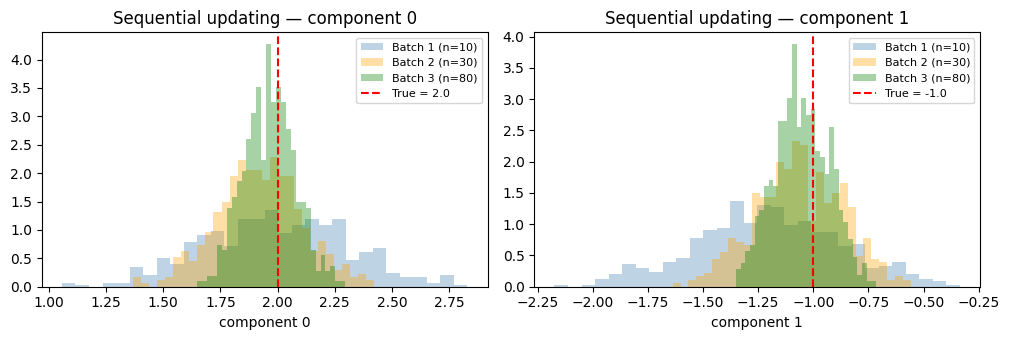

In [6]:
# Visualize posterior convergence (component 0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

colors = ['steelblue', 'orange', 'green']
total_n = 0
for i, (post, n) in enumerate(zip(posteriors, batch_sizes)):
    total_n += n
    ax1.hist(np.array(post.samples[:, 0]), bins=30, density=True,
             alpha=0.35, color=colors[i], label=f'Batch {i+1} (n={total_n})')
    ax2.hist(np.array(post.samples[:, 1]), bins=30, density=True,
             alpha=0.35, color=colors[i], label=f'Batch {i+1} (n={total_n})')

ax1.axvline(true_mean[0], color='red', linestyle='--', label=f'True = {true_mean[0]}')
ax1.set_xlabel('component 0')
ax1.set_title('Sequential updating — component 0')
ax1.legend(fontsize=8)

ax2.axvline(true_mean[1], color='red', linestyle='--', label=f'True = {true_mean[1]}')
ax2.set_xlabel('component 1')
ax2.set_title('Sequential updating — component 1')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Swappable Components

The pipeline is modular — swap the likelihood to model a different data-generating process while keeping the same infrastructure.

In [7]:
# Alternative: Laplace (heavy-tailed) likelihood
class LaplaceLikelihood(Likelihood):
    """Laplace likelihood — more robust to outliers."""

    def __init__(self, scale: float = 1.0):
        self._scale = scale
        super().__init__()

    @wf
    def log_likelihood(self, params, data):
        return jnp.sum(-jnp.abs(data - params) / self._scale - jnp.log(2 * self._scale))


# 2D data with outliers
clean_data = rng.normal(size=(40, 2)) * 0.5 + np.array([2.0, -1.0])
outliers = np.array([[10.0, -8.0], [-8.0, 12.0], [12.0, 10.0]])
data_with_outliers = np.concatenate([clean_data, outliers])

prior = MultivariateNormal(loc=jnp.zeros(2), cov=25.0 * jnp.eye(2), name='prior')
sampler = MCMCSampler(algorithm='nuts', num_results=1000, num_warmup=500, seed=1)

# Gaussian likelihood (sensitive to outliers)
post_gaussian = sampler(prior=prior, likelihood=GaussianLikelihood(1.0), data=data_with_outliers)

# Laplace likelihood (robust to outliers)
sampler2 = MCMCSampler(algorithm='nuts', num_results=1000, num_warmup=500, seed=2)
post_laplace = sampler2(prior=prior, likelihood=LaplaceLikelihood(1.0), data=data_with_outliers)

print(f'True mean:      [2.0, -1.0]')
print(f'Data mean:      {np.mean(data_with_outliers, axis=0)}')
print(f'Gaussian post:  {mean(post_gaussian)}')
print(f'Laplace post:   {mean(post_laplace)}')


True mean:      [2.0, -1.0]
Data mean:      [ 2.32081761 -0.63661496]
Gaussian post:  [ 2.3157454  -0.63561124]
Laplace post:   [ 2.151856 -0.975839]


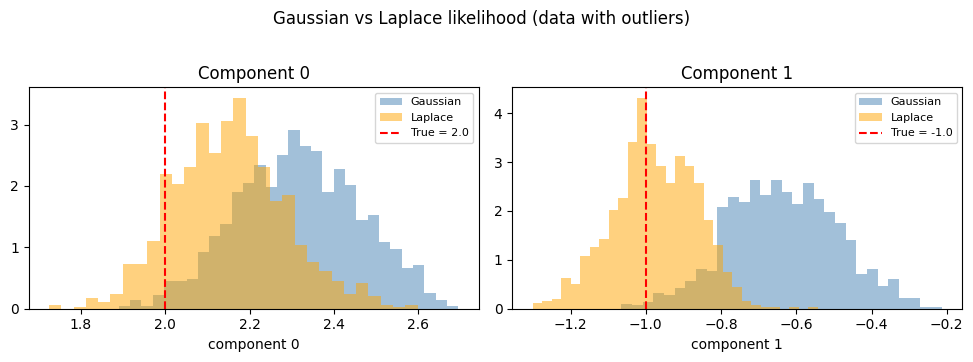

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for comp, ax in enumerate([ax1, ax2]):
    ax.hist(np.array(post_gaussian.samples[:, comp]), bins=30, density=True,
            alpha=0.5, color='steelblue', label=f'Gaussian')
    ax.hist(np.array(post_laplace.samples[:, comp]), bins=30, density=True,
            alpha=0.5, color='orange', label=f'Laplace')
    true_val = [2.0, -1.0][comp]
    ax.axvline(true_val, color='red', linestyle='--', label=f'True = {true_val}')
    ax.set_xlabel(f'component {comp}')
    ax.set_title(f'Component {comp}')
    ax.legend(fontsize=8)
plt.suptitle('Gaussian vs Laplace likelihood (data with outliers)', y=1.02)
plt.tight_layout()
plt.show()


## Posterior Predictive Checks

After inference, generate synthetic data from the posterior to check if the model captures the data-generating process. For each posterior sample $\theta^{(i)}$, draw $y^{(i)} \sim p(y \mid \theta^{(i)})$ — the resulting distribution of $y$ is the **posterior predictive**.

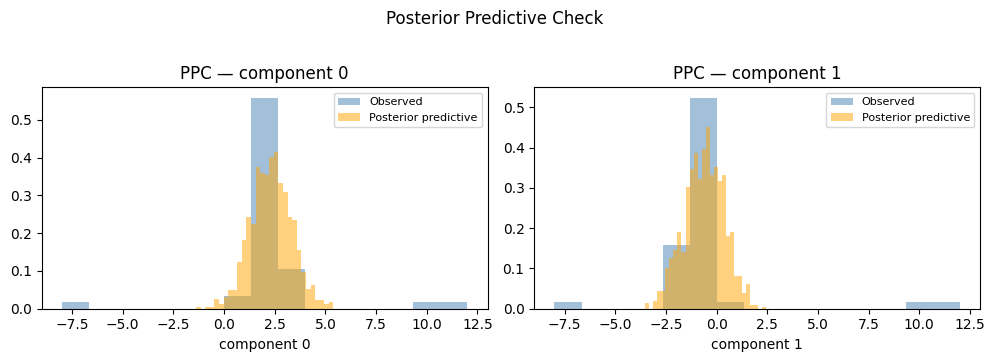

In [9]:
# Posterior predictive: for each posterior sample, generate a data point
posterior_samples = post_gaussian.samples  # (n, 2)
ppc_data = posterior_samples + jax.random.normal(jax.random.PRNGKey(10), posterior_samples.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
for comp, ax in enumerate([ax1, ax2]):
    ax.hist(data_with_outliers[:, comp], bins=15, density=True, alpha=0.5,
            color='steelblue', label='Observed')
    ax.hist(np.array(ppc_data[:, comp]), bins=30, density=True, alpha=0.5,
            color='orange', label='Posterior predictive')
    ax.set_xlabel(f'component {comp}')
    ax.set_title(f'PPC — component {comp}')
    ax.legend(fontsize=8)
plt.suptitle('Posterior Predictive Check', y=1.02)
plt.tight_layout()
plt.show()


## Provenance Tracking Through the Pipeline

Every posterior distribution records how it was created — the algorithm, the prior it descended from, and the sampler settings.

In [10]:
# Each posterior tracks its lineage
post = posteriors[-1]  # final sequential posterior
print(f'Source: {post.source}')
print(f'Algorithm:   {post.source.metadata["algorithm"]}')
print(f'Num results: {post.source.metadata["num_results"]}')

# Trace full ancestry
ancestors = provenance_ancestors(post)
print(f'\nAncestors: {[type(a).__name__ + (f"({a.name})" if a.name else "") for a in ancestors]}')

Source: Provenance('nuts', parents=[posterior])
Algorithm:   nuts
Num results: 500

Ancestors: ['EmpiricalDistribution(posterior)', 'EmpiricalDistribution(posterior)', 'MultivariateNormal(prior)']


## Summary

| Component | Role | Swappable? |
|-----------|------|------------|
| `Likelihood` | Defines $p(\text{data} \mid \theta)$ | Yes — subclass and implement `log_likelihood` |
| `MCMCSampler` | Posterior approximation via NUTS/HMC | Yes — also `RWMH` for non-JAX likelihoods |
| `IterativeForecaster` | Sequential Bayesian updating | Combines any prior + likelihood + sampler |
| `Provenance` | Automatic lineage tracking | Built-in for all operations |

Key takeaways:

- **Define a likelihood** by subclassing `Likelihood` with a `@wf`-decorated `log_likelihood` method.
- **`MCMCSampler`** auto-detects JAX traceability: uses gradient-based NUTS/HMC when possible, falls back to gradient-free RW-MH otherwise.
- **`IterativeForecaster`** chains posterior updates — each batch's posterior becomes the next batch's prior.
- **Swap components freely**: different likelihoods, samplers, or priors can be plugged into the same pipeline.
- **Posterior predictive checks** verify model fit by generating synthetic data from the posterior.